# DocForge — Exploratory Data Analysis

---
### Sections
1. Install & Import
2. Load the Dataset
3. Basic Overview
4. Language Distribution
5. Quality Score Analysis
6. Code Length Analysis
7. Docstring Length Analysis
8. Token Count Estimation
9. Cyclomatic Complexity
10. Per-Language Summary
11. Sample Inspection
12. Key Insights

---
## Section 1 — Install & Import

In [5]:
!pip install datasets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## Section 2 — Load the Dataset

In [6]:
dataset = load_dataset('kaanrkaraman/code2doc')
print(dataset)

df = dataset['train'].to_pandas()
print(f'\nRows: {len(df):,}  |  Columns: {df.shape[1]}')

DatasetDict({
    train: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 10684
    })
    test: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1340
    })
    val: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1334
    })
})

Rows: 10,684  |  Columns: 15


---
## Section 2b — Fix Array-Type Columns

In [7]:
for col in df.columns:
    first_val = df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else None
    if isinstance(first_val, (list, np.ndarray)):
        print(f'Converting column: {col}')
        df[col] = df[col].apply(
            lambda x: ', '.join(str(i) for i in x) if isinstance(x, (list, np.ndarray)) else x
        )

print('\nDtypes after fix:')
print(df.dtypes)

Converting column: parameters

Dtypes after fix:
function_name       object
function_code       object
documentation       object
language            object
file_path           object
line_number          int32
parameters          object
return_type         object
has_type_hints        bool
complexity           int32
quality_score      float32
repo_name           object
repo_stars           int32
docstring_style     object
is_async              bool
dtype: object


---
## Section 3 — Basic Overview

In [8]:
display(df.head(3))

print(f'\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns')

summary = pd.DataFrame({
    'dtype':        df.dtypes,
    'null_count':   df.isnull().sum(),
    'null_pct':     (df.isnull().mean() * 100).round(2),
    'unique_count': df.nunique()
})
print('\nColumn summary:')
display(summary)

print('\nFirst row values:')
for col in df.columns:
    val = str(df[col].iloc[0])[:120]
    print(f'  {col:25s}: {val}')

,function_name,function_code,documentation,language,file_path,line_number,parameters,return_type,has_type_hints,complexity,quality_score,repo_name,repo_stars,docstring_style,is_async
0,parseTypeParameter,function parseTypeParameter(): TypeParameterDe...,Reports a diagnostic error for the current tok...,typescript,src/compiler/parser.ts,3955,,,True,6,6.88,microsoft/TypeScript,107154,jsdoc,False
1,convert,"def convert(self, values: np.ndarray, nan_rep,...",Convert the data from this selection to the ap...,python,pandas/io/pytables.py,2655,"self, values, nan_rep, encoding, errors",,True,15,6.96,pandas-dev/pandas,47362,numpy,False
2,equals,@Override\n\t\tpublic boolean equals(Object ob...,Return the column of the text resource where t...,java,core/spring-boot/src/main/java/org/springframe...,166,obj,,True,6,6.88,spring-projects/spring-boot,79428,javadoc,False



Shape: 10,684 rows × 15 columns

Column summary:


,dtype,null_count,null_pct,unique_count
function_name,object,0,0.0,7511
function_code,object,0,0.0,10684
documentation,object,0,0.0,8616
language,object,0,0.0,5
file_path,object,0,0.0,2599
line_number,int32,0,0.0,2689
parameters,object,0,0.0,4572
return_type,object,0,0.0,1197
has_type_hints,bool,0,0.0,2
complexity,int32,0,0.0,32



First row values:
  function_name            : parseTypeParameter
  function_code            : function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = 
  documentation            : Reports a diagnostic error for the current token being an invalid name.

@param blankDiagnostic Diagnostic to report fo
  language                 : typescript
  file_path                : src/compiler/parser.ts
  line_number              : 3955
  parameters               : 
  return_type              : 
  has_type_hints           : True
  complexity               : 6
  quality_score            : 6.88
  repo_name                : microsoft/TypeScript
  repo_stars               : 107154
  docstring_style          : jsdoc
  is_async                 : False


---
## Section 4 — Language Distribution

Language distribution:
  java           :  6,560  (61.4%)
  python         :  2,885  (27.0%)
  typescript     :    681  (6.4%)
  javascript     :    428  (4.0%)
  cpp            :    130  (1.2%)


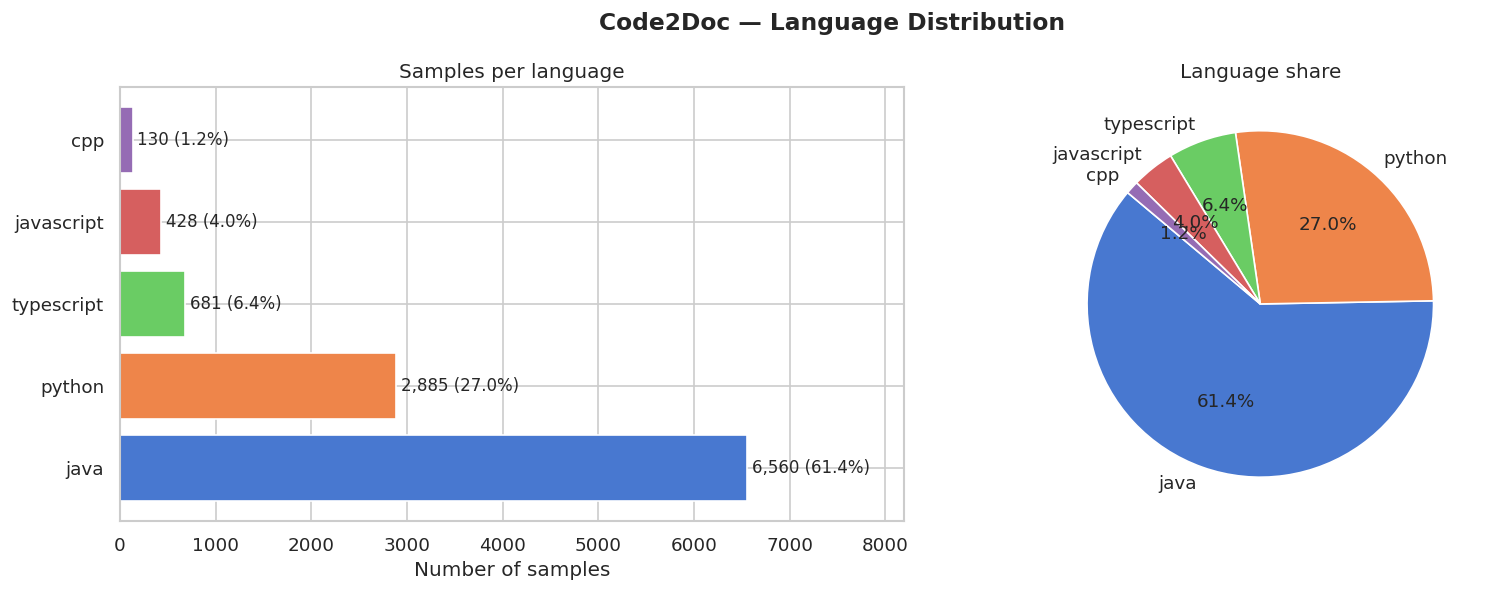


Observation: Java dominates the dataset at 61.4%, reflecting the strong JavaDoc documentation culture in enterprise projects.


In [9]:
lang_counts = df['language'].value_counts()
lang_pct    = (lang_counts / len(df) * 100).round(2)

print('Language distribution:')
for lang, cnt in lang_counts.items():
    print(f'  {lang:15s}: {cnt:6,}  ({lang_pct[lang]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].barh(lang_counts.index, lang_counts.values, color=sns.color_palette('muted', len(lang_counts)))
for bar, cnt, pct in zip(bars, lang_counts.values, lang_pct.values):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=10)
axes[0].set_xlabel('Number of samples')
axes[0].set_title('Samples per language')
axes[0].set_xlim(0, lang_counts.max() * 1.25)

# Pie chart
axes[1].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(lang_counts)), startangle=140)
axes[1].set_title('Language share')

fig.suptitle('Code2Doc — Language Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_language_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nObservation: Java dominates the dataset at {lang_pct.iloc[0]:.1f}%, '
      f'reflecting the strong JavaDoc documentation culture in enterprise projects.')

---
## Section 5 — Quality Score Analysis

Quality score statistics:
  Mean   : 6.925
  Median : 6.800
  Std    : 0.687
  Min    : 6.000
  Max    : 9.680
  Q1     : 6.400
  Q3     : 7.440


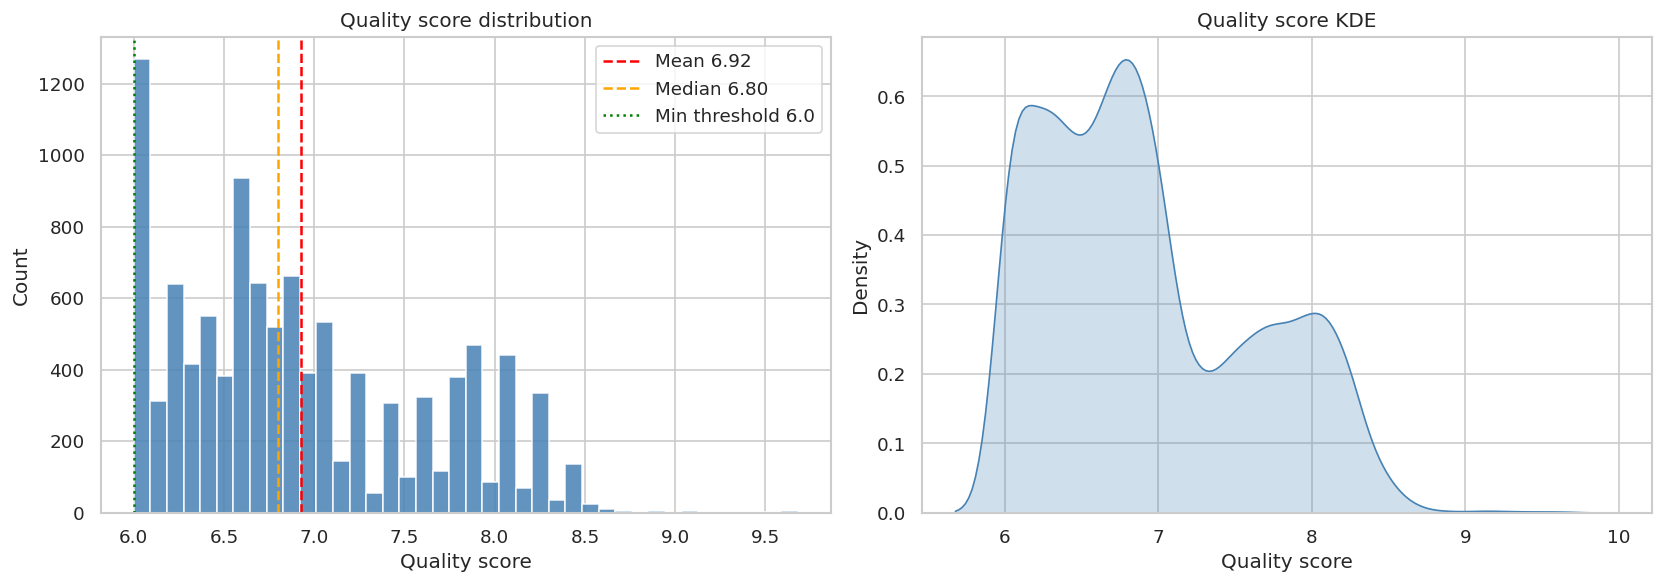

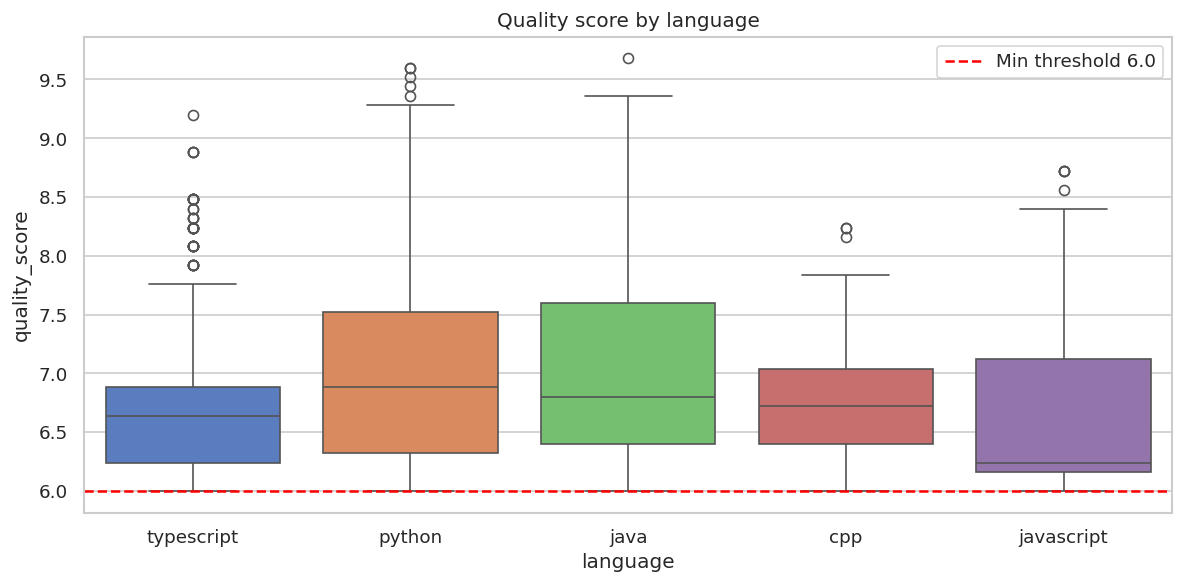


Observation: Quality scores are tightly clustered above 6.0, confirming the dataset filter is effective — nearly all samples are high quality.


In [10]:
qs = df['quality_score']
print('Quality score statistics:')
print(f'  Mean   : {qs.mean():.3f}')
print(f'  Median : {qs.median():.3f}')
print(f'  Std    : {qs.std():.3f}')
print(f'  Min    : {qs.min():.3f}')
print(f'  Max    : {qs.max():.3f}')
print(f'  Q1     : {qs.quantile(0.25):.3f}')
print(f'  Q3     : {qs.quantile(0.75):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(qs, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(qs.mean(),   color='red',    linestyle='--', label=f'Mean {qs.mean():.2f}')
axes[0].axvline(qs.median(), color='orange', linestyle='--', label=f'Median {qs.median():.2f}')
axes[0].axvline(6.0,         color='green',  linestyle=':',  label='Min threshold 6.0')
axes[0].set_xlabel('Quality score')
axes[0].set_ylabel('Count')
axes[0].set_title('Quality score distribution')
axes[0].legend()

# KDE
sns.kdeplot(qs, ax=axes[1], fill=True, color='steelblue')
axes[1].set_xlabel('Quality score')
axes[1].set_title('Quality score KDE')

plt.tight_layout()
plt.show()

# Boxplot by language
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='language', y='quality_score', ax=ax, palette='muted')
ax.axhline(6.0, color='red', linestyle='--', label='Min threshold 6.0')
ax.set_title('Quality score by language')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nObservation: Quality scores are tightly clustered above 6.0, '
      f'confirming the dataset filter is effective — nearly all samples are high quality.')

---
## Section 6 — Code Length Analysis

Code character length stats:
count    10684.00
mean       771.50
std        825.28
min         20.00
25%        197.00
50%        445.00
75%       1069.00
max       4990.00
Name: code_char_len, dtype: float64

Code line count stats:
count    10684.00
mean        20.58
std         21.91
min          1.00
25%          5.00
50%         12.00
75%         29.00
max        164.00
Name: code_line_count, dtype: float64


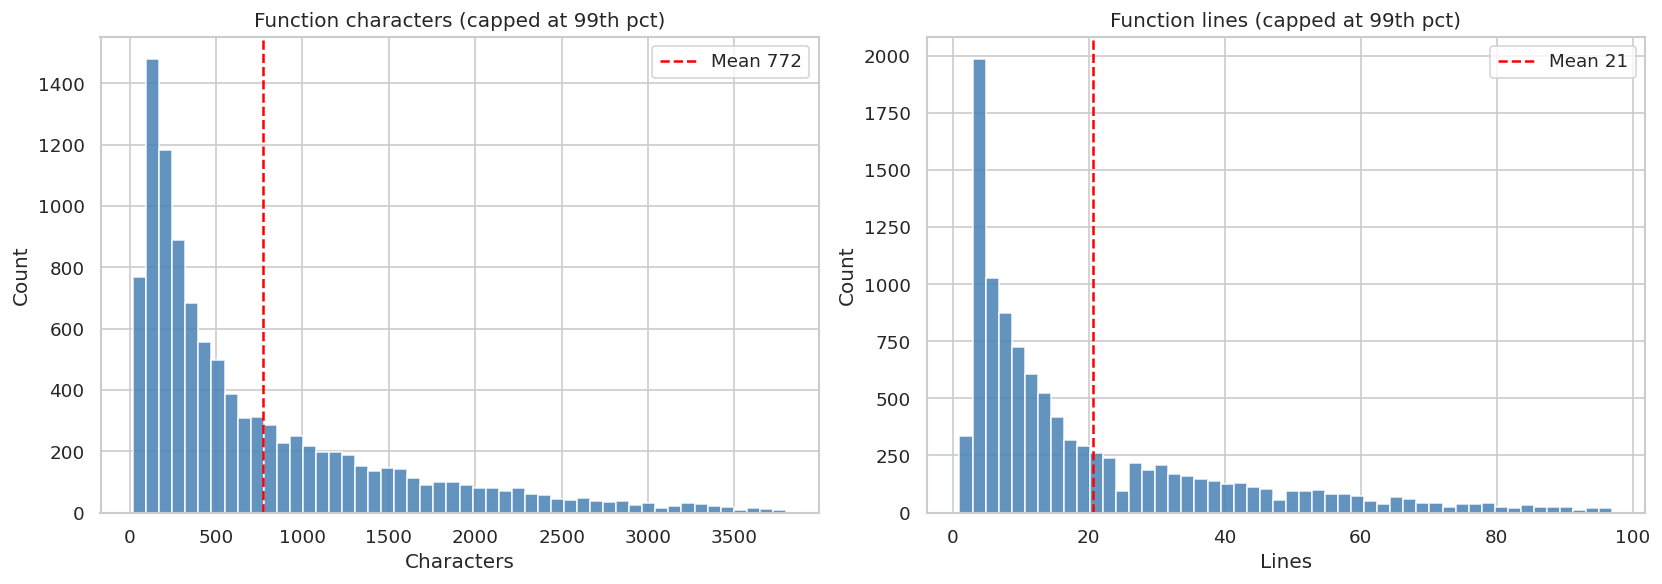


Observation: Most functions are between 197–1069 characters and 5–29 lines, typical of well-scoped, single-responsibility functions.


In [11]:
df['code_char_len']   = df['function_code'].str.len()
df['code_line_count'] = df['function_code'].str.count('\n') + 1

print('Code character length stats:')
print(df['code_char_len'].describe().round(2))
print('\nCode line count stats:')
print(df['code_line_count'].describe().round(2))

cap_char = df['code_char_len'].quantile(0.99)
cap_line = df['code_line_count'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cap, label in [
    (axes[0], 'code_char_len',   cap_char, 'Characters'),
    (axes[1], 'code_line_count', cap_line, 'Lines')
]:
    data = df[col][df[col] <= cap]
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean {df[col].mean():.0f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Function {label.lower()} (capped at 99th pct)')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'\nObservation: Most functions are between '
      f'{int(df["code_char_len"].quantile(0.25))}–{int(df["code_char_len"].quantile(0.75))} characters '
      f'and {int(df["code_line_count"].quantile(0.25))}–{int(df["code_line_count"].quantile(0.75))} lines, '
      f'typical of well-scoped, single-responsibility functions.')

---
## Section 7 — Docstring Length Analysis

Docstring char length stats:
count    10684.00
mean       410.32
std        364.14
min         50.00
25%        167.00
50%        285.00
75%        516.00
max       1998.00
Name: doc_char_len, dtype: float64

Docstring word count stats:
count    10684.00
mean        59.84
std         51.40
min          3.00
25%         26.00
50%         43.00
75%         76.00
max        325.00
Name: doc_word_count, dtype: float64


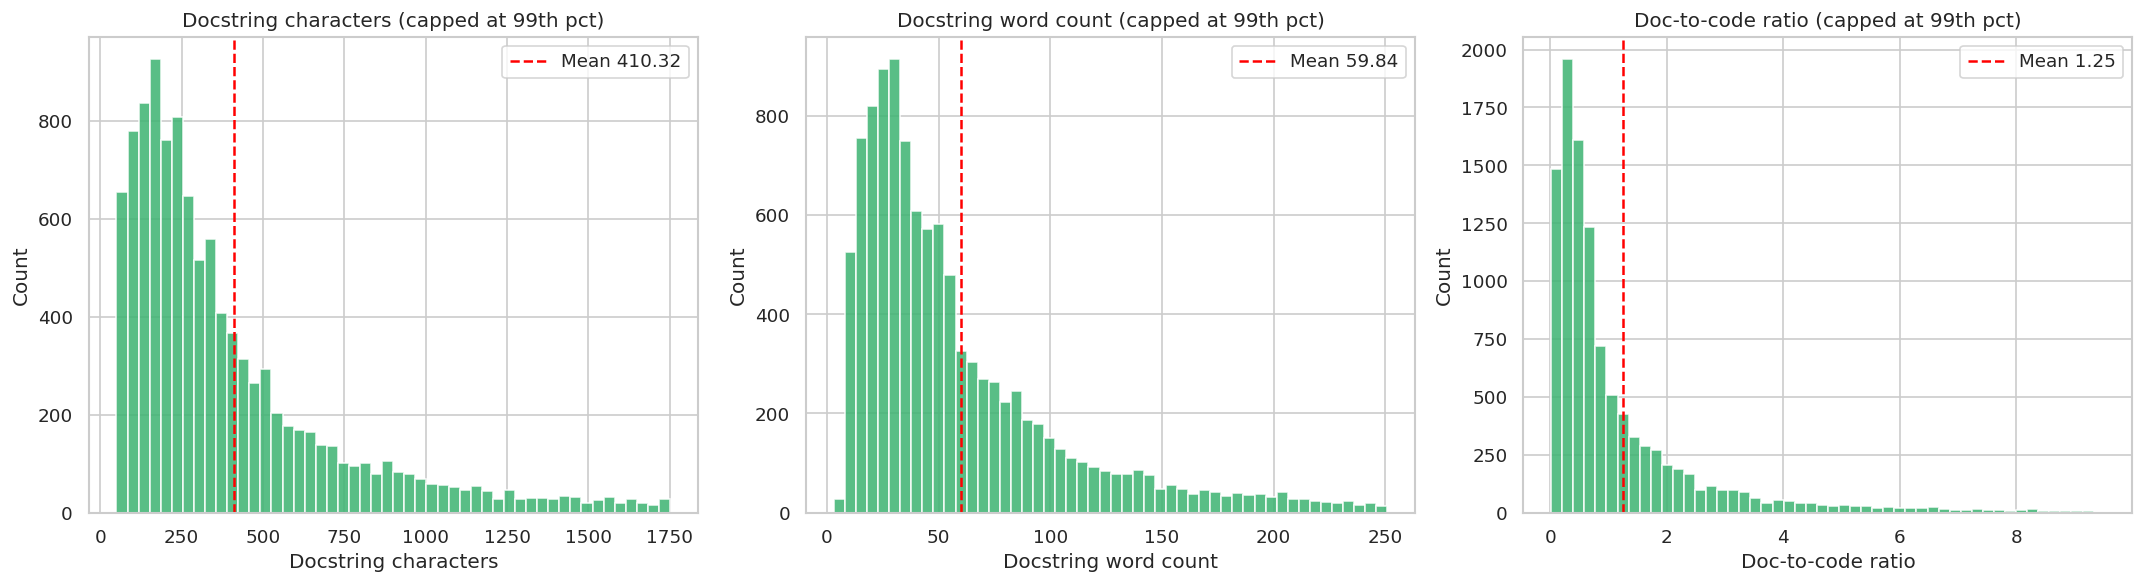


Observation: The median doc-to-code ratio is 0.62, meaning docstrings are typically shorter than the code itself — manageable targets for generation.


In [12]:
df['doc_char_len']  = df['documentation'].str.len()
df['doc_word_count'] = df['documentation'].str.split().str.len()

print('Docstring char length stats:')
print(df['doc_char_len'].describe().round(2))
print('\nDocstring word count stats:')
print(df['doc_word_count'].describe().round(2))

df['doc_to_code_ratio'] = df['doc_char_len'] / df['code_char_len'].replace(0, np.nan)

cap_doc  = df['doc_char_len'].quantile(0.99)
cap_word = df['doc_word_count'].quantile(0.99)
cap_ratio = df['doc_to_code_ratio'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, cap, label in [
    (axes[0], 'doc_char_len',      cap_doc,   'Docstring characters'),
    (axes[1], 'doc_word_count',    cap_word,  'Docstring word count'),
    (axes[2], 'doc_to_code_ratio', cap_ratio, 'Doc-to-code ratio')
]:
    data = df[col].dropna()
    data = data[data <= cap]
    ax.hist(data, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean {df[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} (capped at 99th pct)')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'\nObservation: The median doc-to-code ratio is {df["doc_to_code_ratio"].median():.2f}, '
      f'meaning docstrings are typically shorter than the code itself — manageable targets for generation.')

---
## Section 8 — Token Count Estimation

Code token estimate stats:
count    2000.00
mean      187.76
std       203.50
min         5.00
25%        47.00
50%       105.00
75%       267.25
max      1226.00
Name: code_tokens, dtype: float64

Doc token estimate stats:
count    2000.00
mean       99.35
std        91.09
min        12.00
25%        41.00
50%        68.00
75%       121.00
max       491.00
Name: doc_tokens, dtype: float64


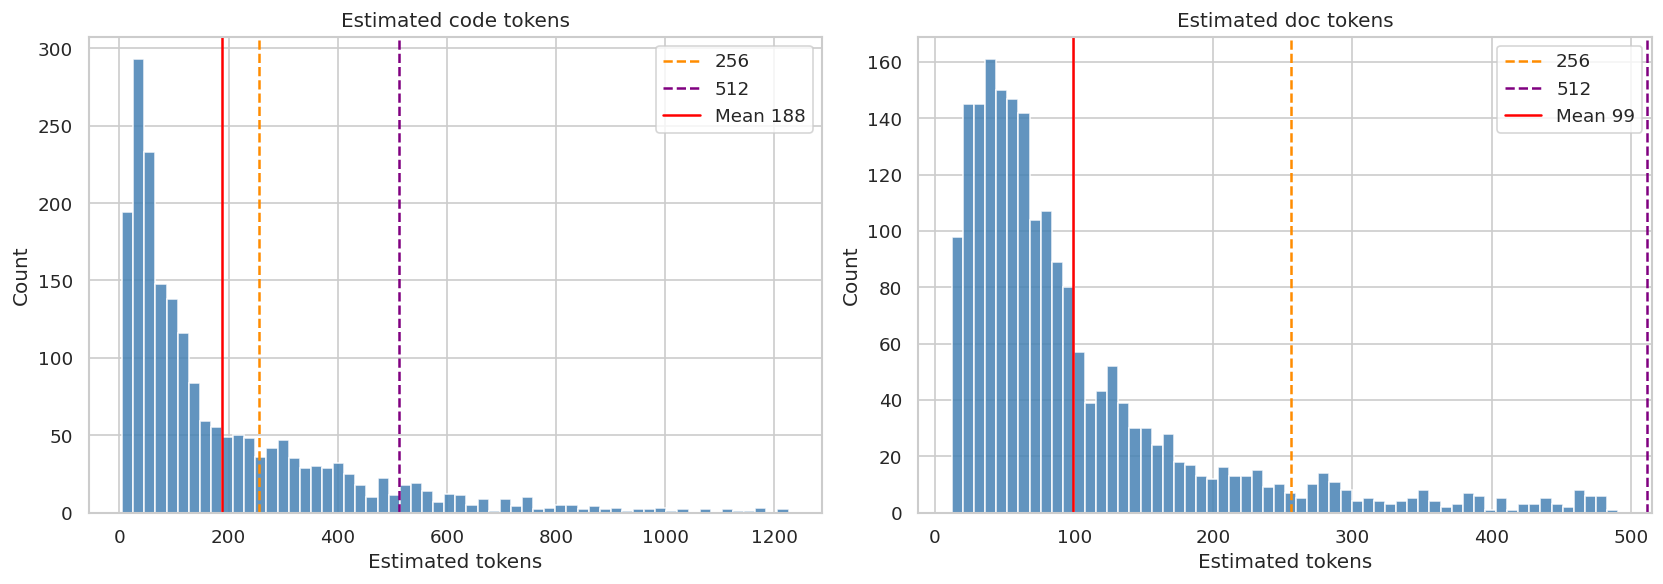


Code token coverage:
  <=  128 tokens : 56.2%
  <=  256 tokens : 74.0%
  <=  512 tokens : 91.6%
  <= 1024 tokens : 99.4%

Doc token coverage:
  <=  64 tokens : 47.0%
  <= 128 tokens : 76.6%
  <= 256 tokens : 92.5%
  <= 512 tokens : 100.0%

Recommended max_input_length  = 512
Recommended max_target_length = 256


In [13]:
sample = df.sample(2000, random_state=42).copy()

sample['code_tokens'] = sample['code_char_len'] // 4
sample['doc_tokens']  = sample['doc_char_len']  // 4

print('Code token estimate stats:')
print(sample['code_tokens'].describe().round(2))
print('\nDoc token estimate stats:')
print(sample['doc_tokens'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], 'code_tokens', 'Estimated code tokens'),
    (axes[1], 'doc_tokens',  'Estimated doc tokens')
]:
    ax.hist(sample[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(256, color='darkorange', linestyle='--', label='256')
    ax.axvline(512, color='purple',     linestyle='--', label='512')
    ax.axvline(sample[col].mean(), color='red', linestyle='-', label=f'Mean {sample[col].mean():.0f}')
    ax.set_xlabel('Estimated tokens')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print('\nCode token coverage:')
for limit in [128, 256, 512, 1024]:
    pct = (sample['code_tokens'] <= limit).mean() * 100
    print(f'  <= {limit:4d} tokens : {pct:.1f}%')

print('\nDoc token coverage:')
for limit in [64, 128, 256, 512]:
    pct = (sample['doc_tokens'] <= limit).mean() * 100
    print(f'  <= {limit:3d} tokens : {pct:.1f}%')

print('\nRecommended max_input_length  = 512')
print('Recommended max_target_length = 256')

---
## Section 9 — Cyclomatic Complexity

Complexity stats:
  Mean   : 3.37
  Median : 2.00
  Std    : 3.08
  Min    : 1
  Max    : 51


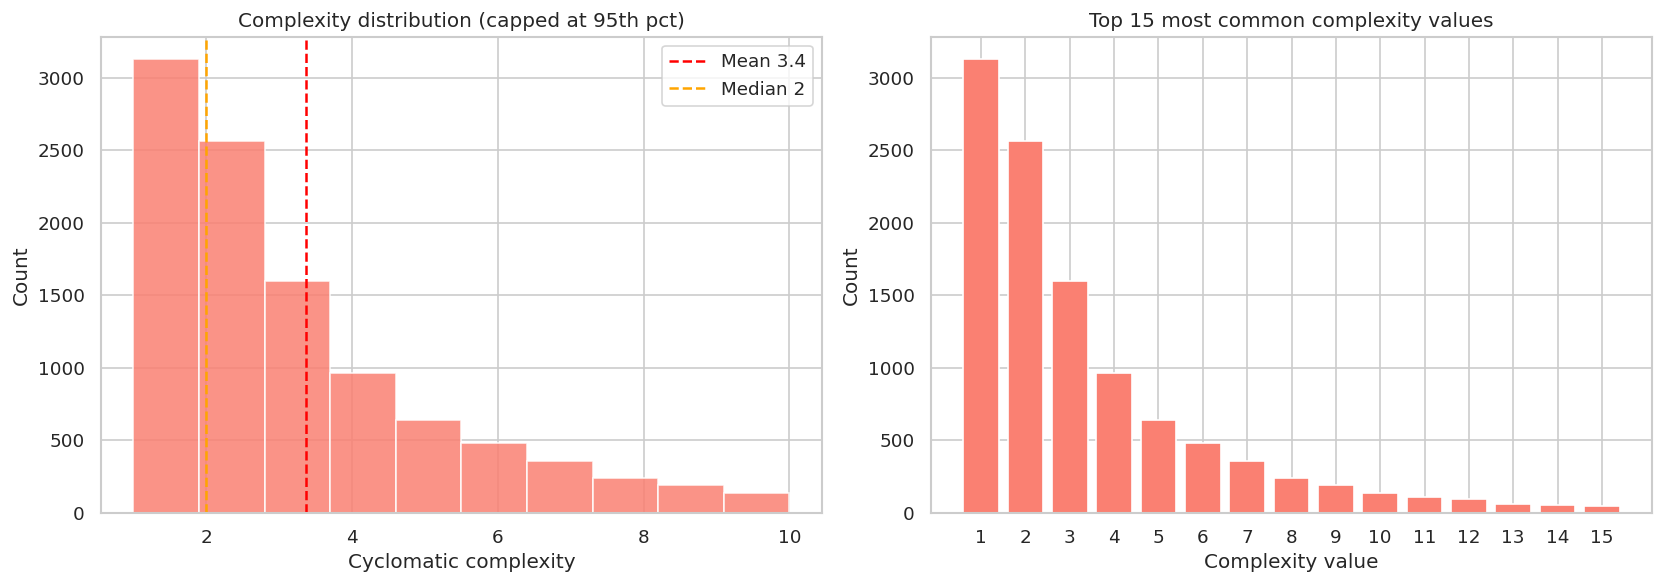


Observation: Most functions have a complexity of 2–4, indicating moderately simple code that is neither trivial nor too branchy to document.


In [14]:
cc = df['complexity']
print('Complexity stats:')
print(f'  Mean   : {cc.mean():.2f}')
print(f'  Median : {cc.median():.2f}')
print(f'  Std    : {cc.std():.2f}')
print(f'  Min    : {cc.min()}')
print(f'  Max    : {cc.max()}')

cap_cc = cc.quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
data = cc[cc <= cap_cc]
axes[0].hist(data, bins=int(cap_cc), color='salmon', edgecolor='white', alpha=0.85)
axes[0].axvline(cc.mean(),   color='red',    linestyle='--', label=f'Mean {cc.mean():.1f}')
axes[0].axvline(cc.median(), color='orange', linestyle='--', label=f'Median {cc.median():.0f}')
axes[0].set_xlabel('Cyclomatic complexity')
axes[0].set_ylabel('Count')
axes[0].set_title('Complexity distribution (capped at 95th pct)')
axes[0].legend()

# Top 15 values
top_vals = cc.value_counts().head(15).sort_index()
axes[1].bar(top_vals.index.astype(str), top_vals.values, color='salmon', edgecolor='white')
axes[1].set_xlabel('Complexity value')
axes[1].set_ylabel('Count')
axes[1].set_title('Top 15 most common complexity values')

plt.tight_layout()
plt.show()

print(f'\nObservation: Most functions have a complexity of {int(cc.median())}–{int(cc.quantile(0.75))}, '
      f'indicating moderately simple code that is neither trivial nor too branchy to document.')

---
## Section 10 — Per-Language Summary

Per-language summary:


,samples,avg_code_chars,avg_code_lines,avg_doc_chars,avg_doc_words,avg_quality,avg_complexity
language,,,,,,,
cpp,130,594.32,17.17,141.98,22.65,6.72,3.76
java,6560,446.38,11.05,347.91,50.96,6.96,2.70
javascript,428,505.48,16.53,338.39,50.55,6.62,4.04
python,2885,1530.99,43.25,607.84,87.34,6.96,4.50
typescript,681,886.93,19.64,271.15,41.84,6.64,4.56


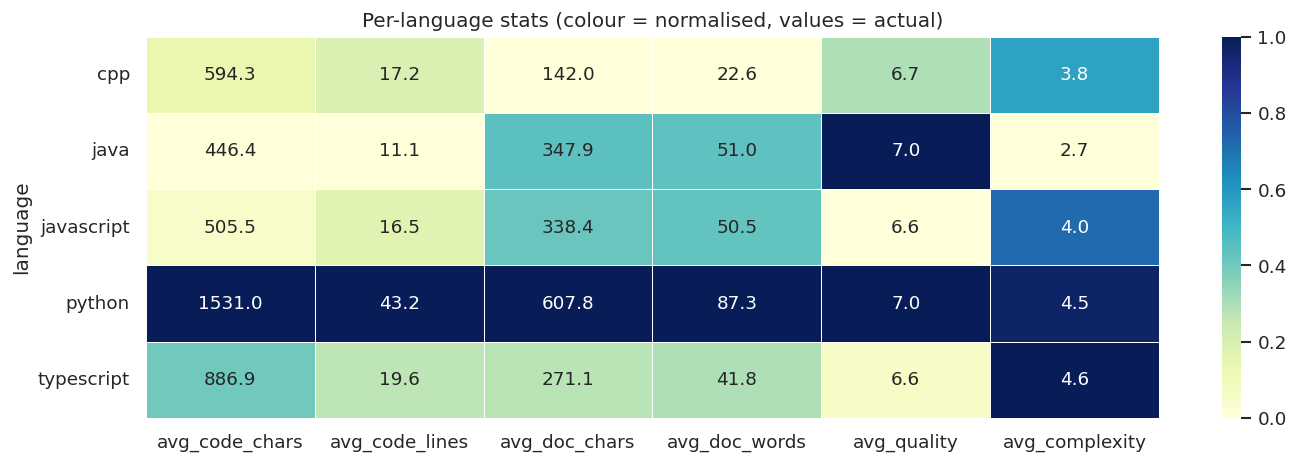

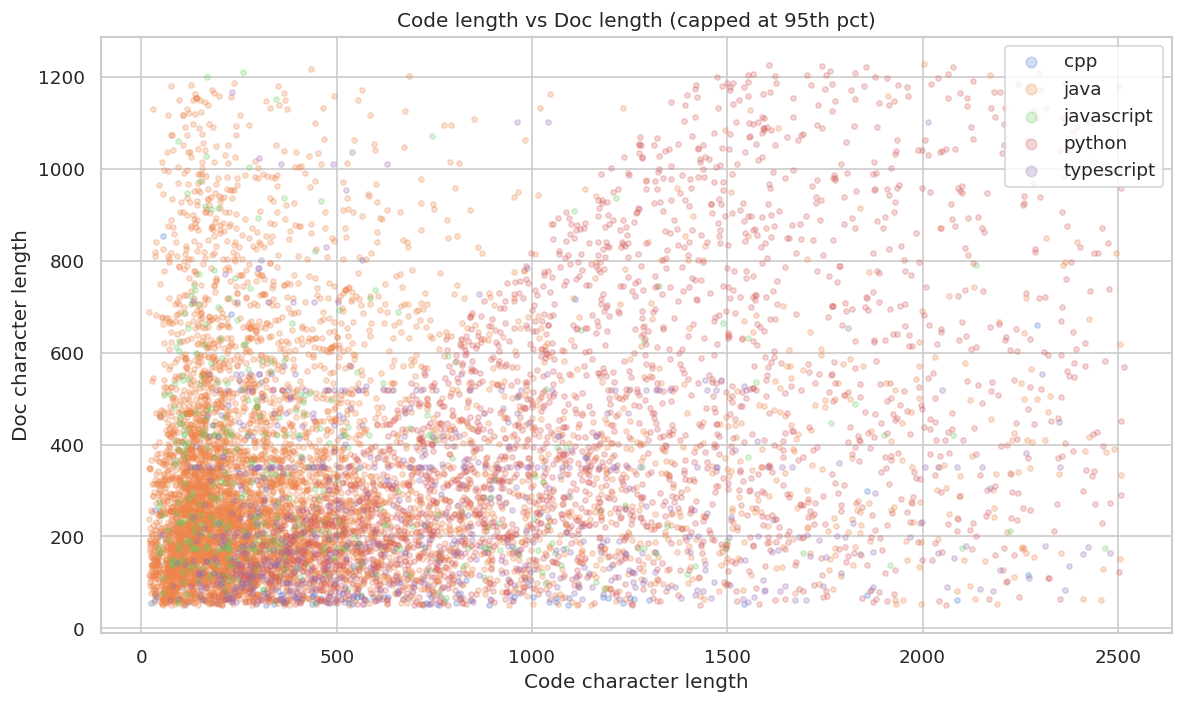

In [15]:
lang_summary = df.groupby('language').agg(
    samples        = ('function_code',  'count'),
    avg_code_chars = ('code_char_len',  'mean'),
    avg_code_lines = ('code_line_count','mean'),
    avg_doc_chars  = ('doc_char_len',   'mean'),
    avg_doc_words  = ('doc_word_count', 'mean'),
    avg_quality    = ('quality_score',  'mean'),
    avg_complexity = ('complexity',     'mean')
).round(2)

print('Per-language summary:')
display(lang_summary)

# Heatmap — normalize per column so colours are comparable
numeric_cols = lang_summary.columns[1:]  # skip sample count
norm_summary = (lang_summary[numeric_cols] - lang_summary[numeric_cols].min()) / \
               (lang_summary[numeric_cols].max() - lang_summary[numeric_cols].min())

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(norm_summary, annot=lang_summary[numeric_cols], fmt='.1f',
            cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Per-language stats (colour = normalised, values = actual)')
plt.tight_layout()
plt.show()

# Scatter: code length vs doc length coloured by language
cap_x = df['code_char_len'].quantile(0.95)
cap_y = df['doc_char_len'].quantile(0.95)
scatter_df = df[(df['code_char_len'] <= cap_x) & (df['doc_char_len'] <= cap_y)]

fig, ax = plt.subplots(figsize=(10, 6))
for lang, grp in scatter_df.groupby('language'):
    ax.scatter(grp['code_char_len'], grp['doc_char_len'], label=lang, alpha=0.25, s=10)
ax.set_xlabel('Code character length')
ax.set_ylabel('Doc character length')
ax.set_title('Code length vs Doc length (capped at 95th pct)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
## Section 11 — Sample Inspection

In [16]:
def print_sample(row):
    print('=' * 70)
    print(f'Language      : {row["language"]}')
    print(f'Quality score : {row["quality_score"]}')
    print('-' * 70)
    print('FUNCTION CODE:')
    print(str(row['function_code'])[:500])
    print('-' * 70)
    print('DOCUMENTATION:')
    print(str(row['documentation'])[:400])
    print('=' * 70)

print('--- Python sample ---')
py_row = df[df['language'] == 'python'].iloc[0]
print_sample(py_row)

print('\n--- Java sample ---')
java_row = df[df['language'] == 'java'].iloc[0]
print_sample(java_row)

print('\n--- Top 3 by quality score ---')
for _, row in df.nlargest(3, 'quality_score').iterrows():
    print_sample(row)

--- Python sample ---
Language      : python
Quality score : 6.960000038146973
----------------------------------------------------------------------
FUNCTION CODE:
def convert(self, values: np.ndarray, nan_rep, encoding: str, errors: str):
        """
        Convert the data from this selection to the appropriate pandas type.

        Parameters
        ----------
        values : np.ndarray
        nan_rep :
        encoding : str
        errors : str

        Returns
        -------
        index : listlike to become an Index
        data : ndarraylike to become a column
        """
        assert isinstance(values, np.ndarray), type(values)

        # 
----------------------------------------------------------------------
DOCUMENTATION:
Convert the data from this selection to the appropriate pandas type.

Parameters
----------
values : np.ndarray
nan_rep :
encoding : str
errors : str

Returns
-------
index : listlike to become an Index
data : ndarraylike to become a column

--- Ja

---
## Section 12 — Key Insights Summary

In [17]:
total        = len(df)
n_langs      = df['language'].nunique()
dom_lang     = df['language'].value_counts().index[0]
dom_pct      = df['language'].value_counts(normalize=True).iloc[0] * 100
qs_mean      = df['quality_score'].mean()
qs_std       = df['quality_score'].std()
all_above    = 'Yes' if (df['quality_score'] >= 6.0).all() else 'No'
avg_cc       = df['code_char_len'].mean()
avg_cl       = df['code_line_count'].mean()
avg_dc       = df['doc_char_len'].mean()
avg_dw       = df['doc_word_count'].mean()
cc_mean      = df['complexity'].mean()
cc_med       = df['complexity'].median()
pct_512      = (sample['code_tokens'] <= 512).mean() * 100
pct_256      = (sample['doc_tokens']  <= 256).mean() * 100

print('=' * 60)
print('       DOCFORGE EDA — KEY INSIGHTS')
print('=' * 60)
print(f"""
Dataset
  Total samples         : {total:,}
  Number of languages   : {n_langs}
  Dominant language     : {dom_lang} ({dom_pct:.1f}%)

Quality Scores
  Mean                  : {qs_mean:.3f}
  Std deviation         : {qs_std:.3f}
  All samples above 6.0 : {all_above}

Code Length
  Average chars         : {avg_cc:.0f}
  Average lines         : {avg_cl:.1f}

Docstring Length
  Average chars         : {avg_dc:.0f}
  Average words         : {avg_dw:.1f}

Complexity
  Mean cyclomatic CC    : {cc_mean:.2f}
  Median cyclomatic CC  : {cc_med:.0f}

Token Estimates (chars / 4)
  % code fits in 512    : {pct_512:.1f}%
  % doc fits in 256     : {pct_256:.1f}%

Recommended Settings for Notebook 2
  max_input_length      : 512
  max_target_length     : 256
""")
print('=' * 60)

       DOCFORGE EDA — KEY INSIGHTS

Dataset
  Total samples         : 10,684
  Number of languages   : 5
  Dominant language     : java (61.4%)

Quality Scores
  Mean                  : 6.925
  Std deviation         : 0.687
  All samples above 6.0 : Yes

Code Length
  Average chars         : 772
  Average lines         : 20.6

Docstring Length
  Average chars         : 410
  Average words         : 59.8

Complexity
  Mean cyclomatic CC    : 3.37
  Median cyclomatic CC  : 2

Token Estimates (chars / 4)
  % code fits in 512    : 91.6%
  % doc fits in 256     : 92.5%

Recommended Settings for Notebook 2
  max_input_length      : 512
  max_target_length     : 256

